In [1]:
# ============================================================
# 셀 1 - 라이브러리 임포트 및 경로 설정
# CLIP vision encoder의 Layer Normalization만 파인튜닝합니다.
# 전체 파라미터의 0.03%만 학습하므로 기존 ViT 전체 파인튜닝보다
# 훨씬 가볍고 일반화 성능이 높습니다.
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import json
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import transforms
from transformers import CLIPModel, CLIPProcessor
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
from datetime import datetime

BASE_DIR  = Path(r"C:\Users\user\Desktop\deepfake-detector")
MODEL_DIR = BASE_DIR / "models" / "clip_lndf"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [2]:
# ============================================================
# 셀 2 - 데이터 로드 및 train/val 분할
# real: data/real_frames/ (documentary + vlog)
# fake: data/vidprom/frames/fake/
# 클래스 불균형(real 86K vs fake 12K) 처리를 위해
# real을 fake 수에 맞게 언더샘플링합니다.
# ============================================================

import random
random.seed(42)

real_frames = (
    list((BASE_DIR / "data" / "real_frames" / "documentary").glob("*.jpg")) +
    list((BASE_DIR / "data" / "real_frames" / "vlog").glob("*.jpg"))
)
fake_frames = list((BASE_DIR / "data" / "vidprom" / "frames" / "fake").glob("*.jpg"))

print(f"전체 real: {len(real_frames)}장")
print(f"전체 fake: {len(fake_frames)}장")

# 클래스 균형 맞추기 — real을 fake 수에 맞게 언더샘플링
real_sampled = random.sample(real_frames, len(fake_frames))

# 경로 + 레이블 합치기 (0=real, 1=fake)
all_data = [(p, 0) for p in real_sampled] + [(p, 1) for p in fake_frames]
random.shuffle(all_data)

train_data, val_data = train_test_split(all_data, test_size=0.1, random_state=42)

print(f"\n언더샘플링 후 real: {len(real_sampled)}장")
print(f"train: {len(train_data)}장 | val: {len(val_data)}장")

전체 real: 86067장
전체 fake: 12521장

언더샘플링 후 real: 12521장
train: 22537장 | val: 2505장


In [3]:
# ============================================================
# 셀 3 - Dataset 정의
# CLIP 입력 규격에 맞게 전처리합니다.
# CLIPProcessor 대신 직접 transform을 정의해서
# DataLoader와 호환되도록 합니다.
# ============================================================

class DeepfakeDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data  # [(path, label), ...]
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        path, label = self.data[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

# CLIP 입력 규격: 224×224, ImageNet 정규화
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.48145466, 0.4578275, 0.40821073],  # CLIP 전용 mean
        std=[0.26862954, 0.26130258, 0.27577711]    # CLIP 전용 std
    ),
])

train_dataset = DeepfakeDataset(train_data, transform=transform)
val_dataset   = DeepfakeDataset(val_data,   transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0)

print(f"train 배치 수: {len(train_loader)}")
print(f"val 배치 수:   {len(val_loader)}")

train 배치 수: 705
val 배치 수:   79


In [11]:
# ============================================================
# 셀 4 - CLIP 모델 로드 및 Layer Norm 파라미터만 학습 설정
# CLIP vision encoder 전체를 freeze하고
# Layer Normalization 파라미터만 unfreeze합니다.
# 전체 파라미터의 약 0.03%만 학습 → 빠르고 일반화 좋음
# 분류 head(Linear)는 새로 추가합니다.
# ============================================================

class CLIPLayerNormDetector(nn.Module):
    def __init__(self):
        super().__init__()

        # CLIP vision encoder 로드
        clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
        self.vision_encoder = clip.vision_model

        # 전체 파라미터 freeze
        for param in self.vision_encoder.parameters():
            param.requires_grad = False

        # Layer Normalization 파라미터만 unfreeze
        for name, module in self.vision_encoder.named_modules():
            if isinstance(module, nn.LayerNorm):
                for param in module.parameters():
                    param.requires_grad = True

        # 분류 head (CLIP vision output dim = 768)
        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)  # real / fake
        )

    def forward(self, x):
        # CLIP vision encoder 통과
        outputs = self.vision_encoder(pixel_values=x)
        # CLS 토큰 사용
        cls_token = outputs.last_hidden_state[:, 0, :]  # (B, 768)
        # L2 정규화 (하이퍼스피어 feature manifold)
        cls_token = nn.functional.normalize(cls_token, p=2, dim=1)
        logits = self.classifier(cls_token)
        return logits

model = CLIPLayerNormDetector().to(DEVICE)

# 학습 파라미터 수 확인
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"전체 파라미터:    {total_params:,}")
print(f"학습 파라미터:    {trainable_params:,}")
print(f"학습 비율:        {trainable_params/total_params*100:.3f}%")

config.json: 0.00B [00:00, ?B/s]

C:\Users\user\miniconda3\envs\deepfake\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


전체 파라미터:    87,653,378
학습 파라미터:    237,314
학습 비율:        0.271%


In [12]:
# ============================================================
# 셀 5 - 학습 및 검증 함수 정의
# train_epoch: 한 에폭 학습 (Layer Norm + classifier만 업데이트)
# val_epoch:   한 에폭 검증 (accuracy, loss 측정)
# ============================================================

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, (imgs, labels) in enumerate(loader):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if (batch_idx + 1) % 50 == 0:
            print(f"  배치 [{batch_idx+1}/{len(loader)}] "
                  f"loss: {loss.item():.4f} | "
                  f"acc: {correct/total*100:.2f}%")

    return total_loss / len(loader), correct / total * 100


def val_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total * 100

In [10]:
# ============================================================
# 셀 6 - 체크포인트 저장/로드
# 매 에폭 checkpoint.pth 저장 (이어받기용)
# val_acc 개선 시 best_model.pth 별도 저장
# ============================================================

CHECKPOINT_PATH = MODEL_DIR / "checkpoint.pth"
BEST_MODEL_PATH = MODEL_DIR / "best_model.pth"
HISTORY_PATH    = MODEL_DIR / "history.json"

def save_checkpoint(model, optimizer, epoch, best_val_acc, history):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_acc": best_val_acc,
    }, CHECKPOINT_PATH)
    with open(HISTORY_PATH, "w") as f:
        json.dump(history, f)

def load_checkpoint(model, optimizer):
    if not CHECKPOINT_PATH.exists():
        print("체크포인트 없음 — 처음부터 학습 시작")
        return 0, 0.0, {"train_loss": [], "val_loss": [],
                        "train_acc": [], "val_acc": []}
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    history = json.load(open(HISTORY_PATH)) if HISTORY_PATH.exists() else \
              {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    print(f"체크포인트 로드: epoch {ckpt['epoch']} | "
          f"best_val_acc: {ckpt['best_val_acc']:.2f}%")
    return ckpt["epoch"], ckpt["best_val_acc"], history

In [ ]:
# ============================================================
# 셀 7 - 학습 실행
# 총 20 에폭, Layer Norm + classifier만 학습
# optimizer: AdamW (lr=1e-4)
# 5 에폭마다 스냅샷 저장
# 시작/종료 시간 및 총 소요 시간 출력
# ============================================================

EPOCHS        = 20
LR            = 1e-4
SAVE_INTERVAL = 5

criterion = nn.CrossEntropyLoss()
# Layer Norm + classifier 파라미터만 optimizer에 등록
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR
)

start_epoch, best_val_acc, history = load_checkpoint(model, optimizer)

start_time = datetime.now()
print(f"학습 시작 (epoch {start_epoch+1} ~ {EPOCHS})")
print(f"Device: {DEVICE}")
print(f"시작 시간: {start_time.strftime('%Y-%m-%d %H:%M:%S')}\n")

for epoch in range(start_epoch, EPOCHS):
    epoch_start = datetime.now()

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss,   val_acc   = val_epoch(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    elapsed = (datetime.now() - epoch_start).seconds
    print(f"\nEpoch [{epoch+1}/{EPOCHS}] | "
          f"train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | "
          f"train_acc: {train_acc:.2f}% | val_acc: {val_acc:.2f}% | {elapsed}초")

    # best model 저장
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  ✓ best model 저장 (val_acc: {best_val_acc:.2f}%)")

    # 매 에폭 체크포인트 저장
    save_checkpoint(model, optimizer, epoch + 1, best_val_acc, history)

    # 5 에폭마다 스냅샷 저장
    if (epoch + 1) % SAVE_INTERVAL == 0:
        snapshot_path = MODEL_DIR / f"snapshot_epoch{epoch+1:02d}.pth"
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "train_acc": train_acc,
            "val_acc": val_acc,
        }, snapshot_path)
        print(f"  ✓ 스냅샷 저장: snapshot_epoch{epoch+1:02d}.pth")
        print(f"  현재까지 요약:")
        print(f"    - 완료 에폭: {epoch+1}/{EPOCHS}")
        print(f"    - 현재 val_acc: {val_acc:.2f}%")
        print(f"    - 최고 val_acc: {best_val_acc:.2f}%")
        print("-" * 50)

end_time = datetime.now()
elapsed_total = end_time - start_time
hours, remainder = divmod(elapsed_total.seconds, 3600)
minutes, seconds = divmod(remainder, 60)

print("\n학습 완료!")
print(f"시작 시간: {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"종료 시간: {end_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"총 소요 시간: {hours}시간 {minutes}분 {seconds}초")
print(f"최종 best val_acc: {best_val_acc:.2f}%")
print(f"모델 저장 경로: {MODEL_DIR}")

체크포인트 없음 — 처음부터 학습 시작
학습 시작 (epoch 1 ~ 20)
Device: cuda
시작 시간: 2026-04-19 19:03:35

  배치 [50/705] loss: 0.5987 | acc: 68.19%
  배치 [100/705] loss: 0.3725 | acc: 83.41%
  배치 [150/705] loss: 0.2829 | acc: 88.62%
  배치 [200/705] loss: 0.1437 | acc: 91.22%
  배치 [250/705] loss: 0.0522 | acc: 92.80%
  배치 [300/705] loss: 0.0325 | acc: 93.83%
  배치 [350/705] loss: 0.0257 | acc: 94.62%
  배치 [400/705] loss: 0.0141 | acc: 95.23%
  배치 [450/705] loss: 0.0399 | acc: 95.72%
  배치 [500/705] loss: 0.0336 | acc: 96.13%
  배치 [550/705] loss: 0.0083 | acc: 96.47%
  배치 [600/705] loss: 0.0100 | acc: 96.74%
  배치 [650/705] loss: 0.0166 | acc: 96.98%
  배치 [700/705] loss: 0.0053 | acc: 97.19%

Epoch [1/20] | train_loss: 0.1320 | val_loss: 0.0069 | train_acc: 97.20% | val_acc: 99.92% | 267초
  ✓ best model 저장 (val_acc: 99.92%)
  배치 [50/705] loss: 0.0066 | acc: 99.88%
  배치 [100/705] loss: 0.0217 | acc: 99.81%
  배치 [150/705] loss: 0.0030 | acc: 99.85%
  배치 [200/705] loss: 0.0106 | acc: 99.88%
  배치 [250/705] loss: 0.0020

C:\Users\user\AppData\Local\Temp\ipykernel_13068\1741770420.py:25: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_13068\1741770420.py:25: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_13068\1741770420.py:26: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.savefig(str(MODEL_DIR / "train_curve.png"))
C:\Users\user\AppData\Local\Temp\ipykernel_13068\1741770420.py:26: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.savefig(str(MODEL_DIR / "train_curve.png"))
C:\Users\user\miniconda3\envs\deepfake\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\miniconda3\envs\de

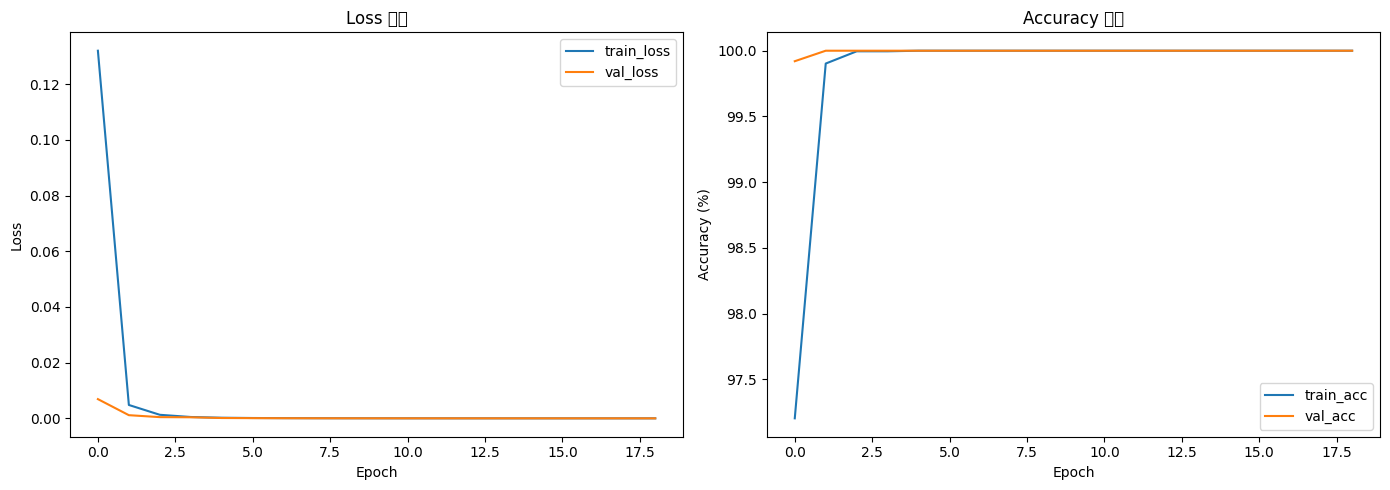

In [14]:
# ============================================================
# 셀 8 - 학습 곡선 시각화
# loss와 accuracy 두 가지를 같이 확인합니다.
# val_acc가 train_acc보다 많이 낮으면 overfitting 신호입니다.
# ============================================================

history = json.load(open(HISTORY_PATH))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="train_loss")
axes[0].plot(history["val_loss"],   label="val_loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss 곡선")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train_acc")
axes[1].plot(history["val_acc"],   label="val_acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy 곡선")
axes[1].legend()

plt.tight_layout()
plt.savefig(str(MODEL_DIR / "train_curve.png"))
plt.show()